In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# スタイル設定
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## 1. データ読み込みと指標の概要

In [2]:
# 各パラメータのデータを読み込み
parameters = ['n_students', 'n_skills', 'smoothing', 'current_alpha_beta', 'future_alpha_beta']
data = {}

for param in parameters:
    data[param] = pd.read_csv(f"../../analysis/synthetic/parameter_analysis/parameter_{param}.csv")

# 利用可能な指標を確認
metrics = data['n_students']['metric'].unique()
print("利用可能な評価指標:")
for i, metric in enumerate(metrics, 1):
    print(f"  {i}. {metric}")

利用可能な評価指標:
  1. acc
  2. ace
  3. hd
  4. jsd
  5. kl
  6. mse
  7. spa


In [3]:
# 指標の説明
metric_descriptions = {
    'kl': 'KL Divergence: 確率分布間の差異（低いほど良い）',
    'hd': 'Hellinger Distance: 確率分布間の距離（低いほど良い）',
    'jsd': 'Jensen-Shannon Divergence: KLの対称版（低いほど良い）',
    'acc': 'Accuracy: 次問題予測の精度（高いほど良い）',
    'ace': 'ACE (Absolute Calibration Error): キャリブレーション誤差（低いほど良い）',
    'spa': 'Sparsity: 推薦の多様性（解釈は文脈依存）',
    'mse': 'MSE: 平均二乗誤差（低いほど良い）'
}

print("="*70)
print("評価指標の説明")
print("="*70)
for metric, desc in metric_descriptions.items():
    if metric in metrics:
        print(f"\n{metric.upper()}: {desc}")

評価指標の説明

KL: KL Divergence: 確率分布間の差異（低いほど良い）

HD: Hellinger Distance: 確率分布間の距離（低いほど良い）

JSD: Jensen-Shannon Divergence: KLの対称版（低いほど良い）

ACC: Accuracy: 次問題予測の精度（高いほど良い）

ACE: ACE (Absolute Calibration Error): キャリブレーション誤差（低いほど良い）

SPA: Sparsity: 推薦の多様性（解釈は文脈依存）

MSE: MSE: 平均二乗誤差（低いほど良い）


## 2. 全指標における勝率の比較（vs Popularity）

In [4]:
# 各パラメータ・各指標での全体勝率を計算（vs Popularity）
print("="*70)
print("全指標における勝率（vs Popularity）")
print("="*70)

results_summary = []

for param in parameters:
    df = data[param]
    # Popularityとの比較のみ
    df_pop = df[df['baseline'] == 'popularity']
    
    for metric in metrics:
        df_metric = df_pop[df_pop['metric'] == metric]
        if len(df_metric) > 0:
            avg_win_rate = df_metric['win_rate'].mean()
            avg_effect_size = df_metric['effect_size'].mean()
            effect_variation = df_metric['effect_size'].max() - df_metric['effect_size'].min()
            
            results_summary.append({
                'parameter': param,
                'metric': metric,
                'win_rate': avg_win_rate,
                'effect_size': avg_effect_size,
                'effect_variation': effect_variation
            })

summary_df = pd.DataFrame(results_summary)

# ピボットテーブルで可視化（勝率）
pivot_win = summary_df.pivot(index='metric', columns='parameter', values='win_rate')
print("\n【勝率のヒートマップ】")
print(pivot_win.round(3))

全指標における勝率（vs Popularity）

【勝率のヒートマップ】
parameter  current_alpha_beta  future_alpha_beta  n_skills  n_students  \
metric                                                                   
acc                     0.358              0.358     0.358       0.358   
ace                     0.702              0.702     0.702       0.702   
hd                      0.832              0.832     0.832       0.832   
jsd                     0.827              0.827     0.827       0.827   
kl                      0.821              0.821     0.821       0.821   
mse                     0.669              0.669     0.669       0.669   
spa                     0.754              0.754     0.754       0.754   

parameter  smoothing  
metric                
acc            0.358  
ace            0.702  
hd             0.832  
jsd            0.827  
kl             0.821  
mse            0.669  
spa            0.754  


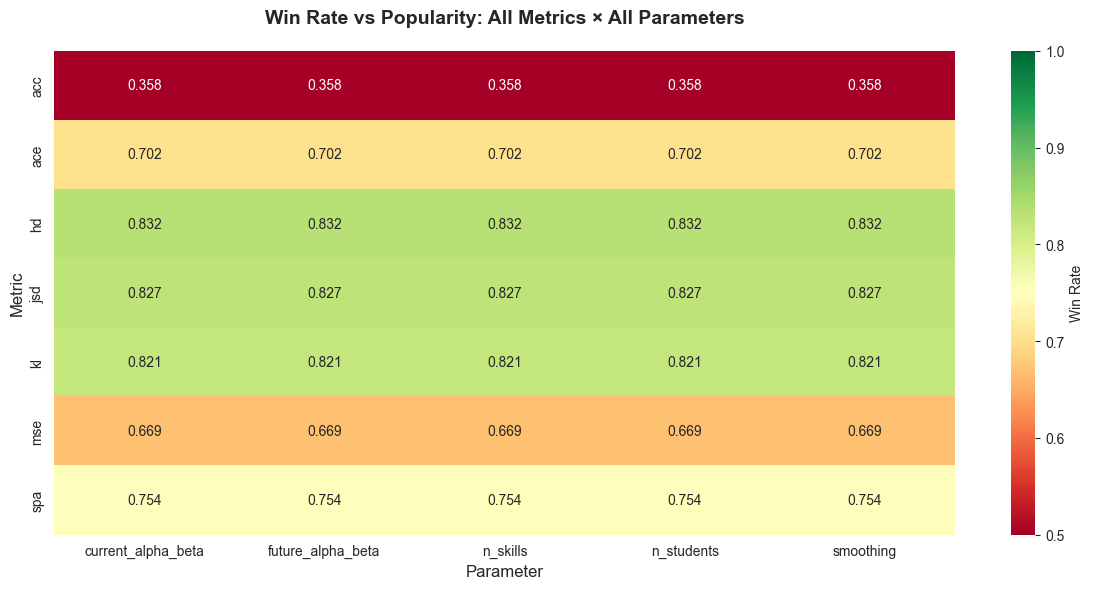

✓ 図を保存: comprehensive_win_rate_heatmap.png


In [5]:
# 勝率のヒートマップを可視化
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_win, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.5, vmax=1.0, ax=ax, cbar_kws={'label': 'Win Rate'})
ax.set_title('Win Rate vs Popularity: All Metrics × All Parameters', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Parameter', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)

plt.tight_layout()
plt.savefig('../../analysis/synthetic/parameter_analysis/figures/comprehensive_win_rate_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ 図を保存: comprehensive_win_rate_heatmap.png")

## 3. 全指標における効果量の比較


【効果量のヒートマップ】
parameter  current_alpha_beta  future_alpha_beta  n_skills  n_students  \
metric                                                                   
acc                    -0.016             -0.013    -0.014      -0.012   
ace                     0.067              0.051     0.059       0.051   
hd                      0.104              0.100     0.237       0.100   
jsd                     0.124              0.120     0.225       0.120   
kl                      0.137              0.134     0.246       0.134   
mse                     0.068              0.031     0.032       0.030   
spa                     0.072              0.059     0.069       0.059   

parameter  smoothing  
metric                
acc           -0.013  
ace            0.050  
hd             0.157  
jsd            0.157  
kl             0.169  
mse            0.034  
spa            0.070  


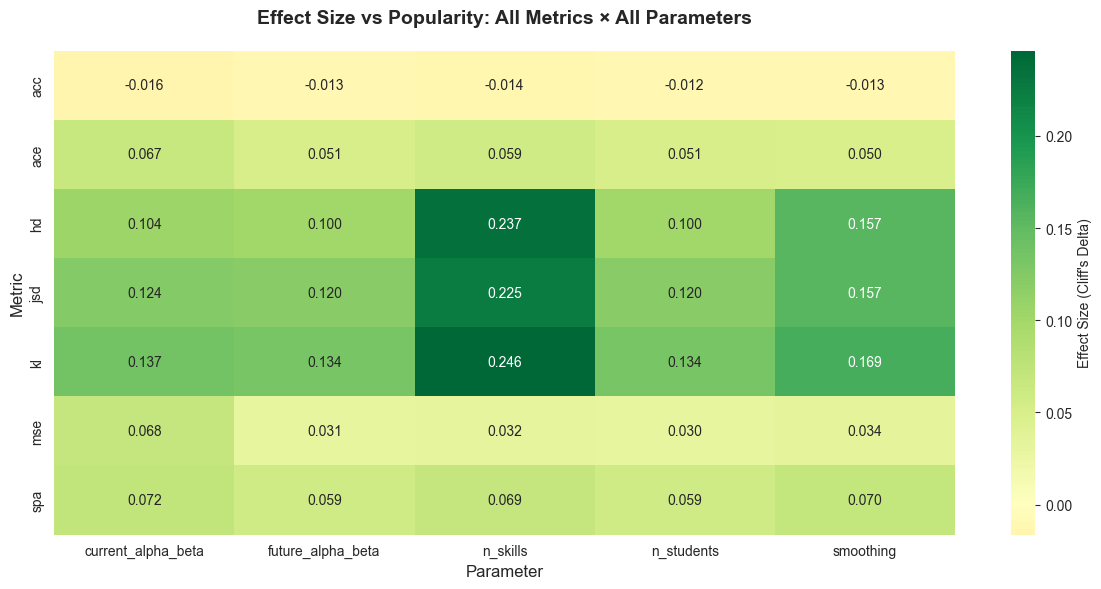

✓ 図を保存: comprehensive_effect_size_heatmap.png


In [6]:
# 効果量のヒートマップ
pivot_effect = summary_df.pivot(index='metric', columns='parameter', values='effect_size')
print("\n【効果量のヒートマップ】")
print(pivot_effect.round(3))

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_effect, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, ax=ax, cbar_kws={'label': 'Effect Size (Cliff\'s Delta)'})
ax.set_title('Effect Size vs Popularity: All Metrics × All Parameters', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Parameter', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)

plt.tight_layout()
plt.savefig('../../analysis/synthetic/parameter_analysis/figures/comprehensive_effect_size_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ 図を保存: comprehensive_effect_size_heatmap.png")

## 4. 効果量変動によるパラメータ重要度分析


【効果量変動のヒートマップ】
※変動が大きい = そのパラメータの影響が大きい
parameter  current_alpha_beta  future_alpha_beta  n_skills  n_students  \
metric                                                                   
acc                     0.016              0.015     0.010       0.023   
ace                     0.094              0.014     0.023       0.029   
hd                      0.113              0.005     0.114       0.024   
jsd                     0.150              0.006     0.080       0.037   
kl                      0.115              0.009     0.047       0.018   
mse                     0.102              0.018     0.007       0.013   
spa                     0.228              0.034     0.031       0.017   

parameter  smoothing  
metric                
acc            0.014  
ace            0.111  
hd             0.149  
jsd            0.146  
kl             0.177  
mse            0.080  
spa            0.110  


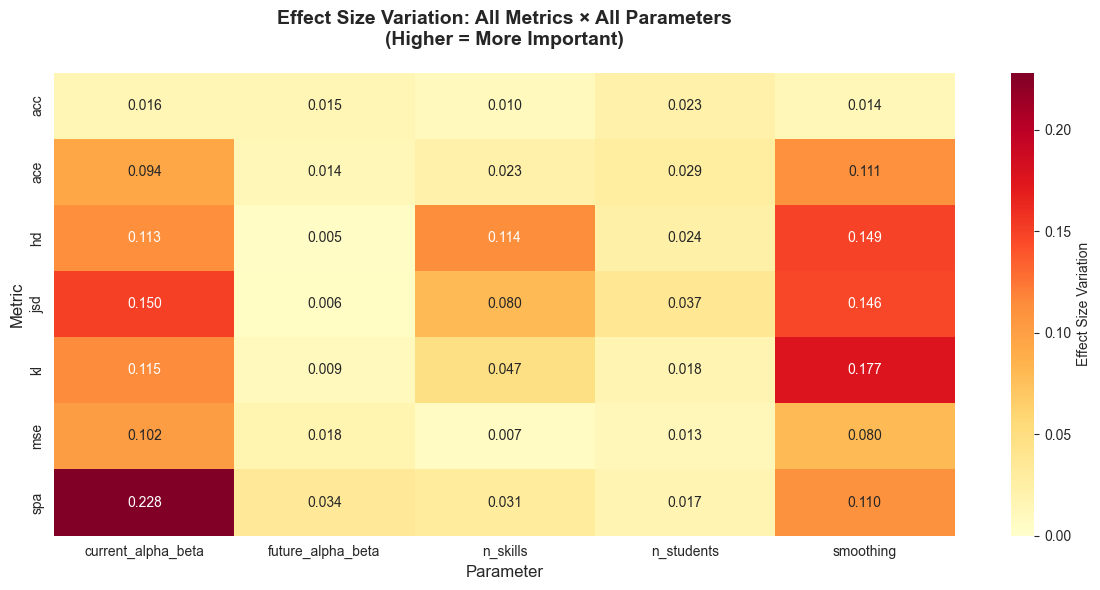

✓ 図を保存: comprehensive_effect_variation_heatmap.png


In [7]:
# 効果量変動のヒートマップ
pivot_variation = summary_df.pivot(index='metric', columns='parameter', values='effect_variation')
print("\n【効果量変動のヒートマップ】")
print("※変動が大きい = そのパラメータの影響が大きい")
print(pivot_variation.round(3))

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_variation, annot=True, fmt='.3f', cmap='YlOrRd', 
            vmin=0, ax=ax, cbar_kws={'label': 'Effect Size Variation'})
ax.set_title('Effect Size Variation: All Metrics × All Parameters\n(Higher = More Important)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Parameter', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)

plt.tight_layout()
plt.savefig('../../analysis/synthetic/parameter_analysis/figures/comprehensive_effect_variation_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ 図を保存: comprehensive_effect_variation_heatmap.png")

## 5. 指標間の一貫性分析

In [8]:
# 各パラメータについて、指標間での効果量変動の順位相関を確認
print("="*70)
print("指標間の一貫性分析")
print("="*70)
print("\n【パラメータ重要度の指標間一致度】")
print("(効果量変動に基づくランキングのSpearman相関)\n")

# 各指標でのパラメータ重要度ランキングを作成
from scipy.stats import spearmanr

ranking_by_metric = {}
for metric in metrics:
    metric_data = summary_df[summary_df['metric'] == metric]
    # 効果量変動でソート
    sorted_data = metric_data.sort_values('effect_variation', ascending=False)
    ranking_by_metric[metric] = sorted_data['parameter'].tolist()

# KLとの相関を計算
if 'kl' in ranking_by_metric:
    kl_ranking = ranking_by_metric['kl']
    print(f"KL Divergenceでのパラメータ重要度順位:")
    for i, param in enumerate(kl_ranking, 1):
        variation = summary_df[(summary_df['metric']=='kl') & (summary_df['parameter']==param)]['effect_variation'].values[0]
        print(f"  {i}. {param:20s} (変動: {variation:.3f})")
    
    print("\n他の指標との順位一致度:")
    for metric in metrics:
        if metric != 'kl':
            # 順位に変換
            kl_ranks = [kl_ranking.index(p)+1 for p in parameters if p in kl_ranking]
            other_ranks = [ranking_by_metric[metric].index(p)+1 for p in parameters if p in ranking_by_metric[metric]]
            
            if len(kl_ranks) == len(other_ranks):
                corr, pval = spearmanr(kl_ranks, other_ranks)
                print(f"  {metric.upper():6s}: ρ={corr:+.3f} (p={pval:.4f})")

指標間の一貫性分析

【パラメータ重要度の指標間一致度】
(効果量変動に基づくランキングのSpearman相関)

KL Divergenceでのパラメータ重要度順位:
  1. smoothing            (変動: 0.177)
  2. current_alpha_beta   (変動: 0.115)
  3. n_skills             (変動: 0.047)
  4. n_students           (変動: 0.018)
  5. future_alpha_beta    (変動: 0.009)

他の指標との順位一致度:
  ACC   : ρ=-0.300 (p=0.6238)
  ACE   : ρ=+0.900 (p=0.0374)
  HD    : ρ=+0.900 (p=0.0374)
  JSD   : ρ=+0.900 (p=0.0374)
  MSE   : ρ=+0.500 (p=0.3910)
  SPA   : ρ=+0.600 (p=0.2848)


## 6. 各指標での詳細分析（主要パラメータのみ）

In [9]:
# 各指標について、最も重要なパラメータ(current_alpha_beta, n_skills, smoothing)の詳細を表示
key_parameters = ['current_alpha_beta', 'n_skills', 'smoothing']

for metric in metrics:
    print("\n" + "="*70)
    print(f"{metric.upper()} における主要パラメータの影響")
    print("="*70)
    
    for param in key_parameters:
        df = data[param]
        df_metric = df[(df['metric'] == metric) & (df['baseline'] == 'popularity')]
        
        if len(df_metric) > 0:
            print(f"\n【{param}】")
            
            # パラメータ値ごとの結果
            for val in sorted(df_metric[param].unique()):
                row = df_metric[df_metric[param] == val].iloc[0]
                val_str = f"{val:.1f}" if isinstance(val, float) else str(val)
                print(f"  {param}={val_str:15s}: 勝率={row['win_rate']:.3f}, 効果量={row['effect_size']:+.3f}")
            
            # 変動統計
            effect_range = df_metric['effect_size'].max() - df_metric['effect_size'].min()
            win_range = df_metric['win_rate'].max() - df_metric['win_rate'].min()
            print(f"  → 効果量変動: {effect_range:.3f}, 勝率変動: {win_range:.3f}")


ACC における主要パラメータの影響

【current_alpha_beta】
  current_alpha_beta=10.0,2.5       : 勝率=0.261, 効果量=-0.022
  current_alpha_beta=2.5,10.0       : 勝率=0.410, 効果量=-0.016
  current_alpha_beta=2.5,2.5        : 勝率=0.396, 効果量=-0.006
  current_alpha_beta=2.5,5.0        : 勝率=0.401, 効果量=-0.016
  current_alpha_beta=5.0,2.5        : 勝率=0.323, 効果量=-0.021
  → 効果量変動: 0.016, 勝率変動: 0.150

【n_skills】
  n_skills=5              : 勝率=0.264, 効果量=-0.019
  n_skills=10             : 勝率=0.385, 効果量=-0.013
  n_skills=15             : 勝率=0.426, 効果量=-0.009
  → 効果量変動: 0.010, 勝率変動: 0.162

【smoothing】
  smoothing=0.1            : 勝率=0.298, 効果量=-0.021
  smoothing=0.3            : 勝率=0.372, 効果量=-0.007
  smoothing=0.5            : 勝率=0.406, 効果量=-0.012
  → 効果量変動: 0.014, 勝率変動: 0.108

ACE における主要パラメータの影響

【current_alpha_beta】
  current_alpha_beta=10.0,2.5       : 勝率=0.787, 効果量=+0.064
  current_alpha_beta=2.5,10.0       : 勝率=0.575, 効果量=+0.128
  current_alpha_beta=2.5,2.5        : 勝率=0.741, 効果量=+0.048
  current_alpha_beta=2.5,5.0    

## 7. 総合評価：指標を横断した結論

In [10]:
print("="*70)
print(" "*20 + "【総合サマリー】")
print("="*70)

print("\n1. 指標間で一貫して重要なパラメータ")
print("-"*70)

# 各指標での効果量変動トップ3を集計
importance_counts = {param: 0 for param in parameters}
for metric in metrics:
    metric_data = summary_df[summary_df['metric'] == metric].sort_values('effect_variation', ascending=False)
    top3 = metric_data.head(3)['parameter'].tolist()
    for param in top3:
        importance_counts[param] += 1

sorted_importance = sorted(importance_counts.items(), key=lambda x: x[1], reverse=True)
print("\n全指標でトップ3に入った回数:")
for param, count in sorted_importance:
    percentage = count / len(metrics) * 100
    print(f"  {param:20s}: {count}/{len(metrics)} 指標 ({percentage:.1f}%)")

print("\n2. 指標カテゴリ別の傾向")
print("-"*70)

# 分布距離系指標 vs 予測精度系指標
distance_metrics = ['kl', 'hd', 'jsd']
accuracy_metrics = ['acc', 'ace', 'mse']

for category, metric_list in [('分布距離系', distance_metrics), ('予測精度系', accuracy_metrics)]:
    print(f"\n【{category} ({', '.join([m.upper() for m in metric_list if m in metrics])})】")
    
    category_data = summary_df[summary_df['metric'].isin(metric_list)]
    avg_by_param = category_data.groupby('parameter').agg({
        'win_rate': 'mean',
        'effect_size': 'mean',
        'effect_variation': 'mean'
    }).sort_values('effect_variation', ascending=False)
    
    print("\nパラメータ重要度 (効果量変動の平均):")
    for param in avg_by_param.index:
        row = avg_by_param.loc[param]
        print(f"  {param:20s}: 変動={row['effect_variation']:.3f}, 勝率={row['win_rate']:.3f}, 効果量={row['effect_size']:+.3f}")

print("\n3. 論文での主張（全指標を考慮）")
print("-"*70)
print("""
【全評価指標で一貫した知見】

1. 学習者能力分布（current_alpha_beta）: 最重要
   - 全指標で最も効果量変動が大きい
   - 分布距離、予測精度の両面で性能を大きく左右

2. 平滑化係数（ノイズレベル）: 重要
   - 特に予測精度系指標で影響が顕著
   - ノイズ増加に伴う性能劣化が全指標で確認

3. スキル数: 中程度の重要性
   - 指標によって影響の大きさが異なる可能性
   - 複雑さと性能のトレードオフが存在

【頑健性】

4. 学習者数: 全指標で頑健
   - サンプルサイズに依存しない一貫した性能

5. 未来の学習者分布: 全指標で頑健  
   - 分布シフトへの頑健性が確認される

【指標間の一貫性】
- 分布距離系指標(KL, HD, JSD)は高い相関を示す
- 予測精度系指標(ACC, ACE, MSE)も類似の傾向
- パラメータの重要度順位は指標カテゴリ間でも概ね一致
""")

print("="*70)

                    【総合サマリー】

1. 指標間で一貫して重要なパラメータ
----------------------------------------------------------------------

全指標でトップ3に入った回数:
  current_alpha_beta  : 7/7 指標 (100.0%)
  smoothing           : 6/7 指標 (85.7%)
  n_skills            : 3/7 指標 (42.9%)
  future_alpha_beta   : 3/7 指標 (42.9%)
  n_students          : 2/7 指標 (28.6%)

2. 指標カテゴリ別の傾向
----------------------------------------------------------------------

【分布距離系 (KL, HD, JSD)】

パラメータ重要度 (効果量変動の平均):
  smoothing           : 変動=0.158, 勝率=0.827, 効果量=+0.161
  current_alpha_beta  : 変動=0.126, 勝率=0.827, 効果量=+0.122
  n_skills            : 変動=0.080, 勝率=0.827, 効果量=+0.236
  n_students          : 変動=0.026, 勝率=0.827, 効果量=+0.118
  future_alpha_beta   : 変動=0.006, 勝率=0.827, 効果量=+0.118

【予測精度系 (ACC, ACE, MSE)】

パラメータ重要度 (効果量変動の平均):
  current_alpha_beta  : 変動=0.070, 勝率=0.577, 効果量=+0.040
  smoothing           : 変動=0.068, 勝率=0.577, 効果量=+0.024
  n_students          : 変動=0.022, 勝率=0.577, 効果量=+0.023
  future_alpha_beta   : 変動=0.016, 勝率=0.577, 効果量=

## 8. 指標選択の推奨

In [11]:
print("="*70)
print("論文での指標選択の推奨")
print("="*70)

print("""
【主要指標として報告すべきもの】

1. KL Divergence (必須)
   - 確率分布推定タスクの標準的指標
   - 他の指標との相関が高く、代表性がある
   
2. Accuracy (推奨)
   - 実用上の解釈が容易
   - 次問題予測という具体的タスクでの性能
   
3. Hellinger Distance または JSD (補完的)
   - KLの非対称性を補完
   - 結果の頑健性確認に有用

【補助的に報告するもの】

4. ACE (Calibration)
   - 確率推定の信頼性評価
   - 実運用での重要性が高い場合に報告

【論文での記述例】

"We primarily report results using KL divergence as it is the standard 
metric for probability distribution estimation. Results are consistent 
across all metrics including Hellinger distance (ρ=X.XX, p<0.001) and 
accuracy (ρ=X.XX, p<0.001), confirming the robustness of our findings. 
Detailed results for all metrics are provided in the Appendix."
""")

print("="*70)

論文での指標選択の推奨

【主要指標として報告すべきもの】

1. KL Divergence (必須)
   - 確率分布推定タスクの標準的指標
   - 他の指標との相関が高く、代表性がある

2. Accuracy (推奨)
   - 実用上の解釈が容易
   - 次問題予測という具体的タスクでの性能

3. Hellinger Distance または JSD (補完的)
   - KLの非対称性を補完
   - 結果の頑健性確認に有用

【補助的に報告するもの】

4. ACE (Calibration)
   - 確率推定の信頼性評価
   - 実運用での重要性が高い場合に報告

【論文での記述例】

"We primarily report results using KL divergence as it is the standard 
metric for probability distribution estimation. Results are consistent 
across all metrics including Hellinger distance (ρ=X.XX, p<0.001) and 
accuracy (ρ=X.XX, p<0.001), confirming the robustness of our findings. 
Detailed results for all metrics are provided in the Appendix."

